In [1]:
import os
import numpy as np
import pandas as pd

from matplotlib import gridspec

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.negloglik_params import *

from dekef.negloglik_grid_points import *
from dekef.scorematching_penalized_grid_points import *

from dekef.plot_density_1d import *

from IPython.display import Markdown as md

from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')
np.random.seed(1989)

In [2]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
waiting = waiting[waiting != 108.0]

bw = 5.
kernel_type = 'gaussian_poly2'

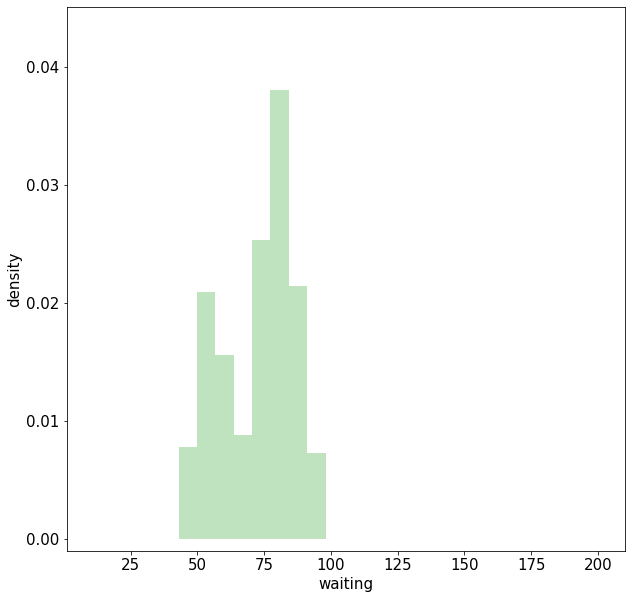

In [3]:
# set plot parameters
font_size = 15
xlimit = (1., 210.)
plot_pts_cnt = 3000
ylimit = (-0.001, 0.0451)

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
                                       bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)

# plt.savefig(f'../plots/histogram.pdf', bbox_inches = 'tight')

In [4]:
108 in waiting

False

In [5]:
base_density = BasedenGamma(waiting, 36., 2.)
base_density.a, base_density.scale

(36.0, 2.0)

In [6]:
seed_no = 1
gap = 1
grid_points = np.arange(1., 202., gap).reshape(-1, 1)
xlimit = (1., 210.)
plot_pts_cnt = 3000

new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)

ml_folder = (f'../data/data=geyser-waiting-PenML-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
             f'grid_points=1-202-{gap}-seed={seed_no}-with108={108 in waiting}')

if not os.path.isdir(ml_folder):
    os.mkdir(ml_folder)

file_name_newdata = f'/new_data.npy'
np.save(ml_folder + file_name_newdata, new_data)

file_name_grid_points = f'/grid_points.npy'
np.save(ml_folder + file_name_grid_points, grid_points)

In [7]:
nll_pen = NegLogLikGridPoints(
    data = waiting, 
    grid_points = grid_points, 
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw
)

In [8]:
# set parameters for computing the density estimate
bmc_params = batch_montecarlo_params(
    mc_batch_size = 5000, 
    mc_tol = 5e-3)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.6, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

ml_log_pen_param_list = [-np.inf, -15., -14., -13., -12., -11., -10., -9., -8., -7., -6.]

**************************************************
log penalty = -inf
start time = 08:44:09
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.28397929251016324, Relative Error = 0.3533217501289988
Iter = 3, GradNorm = 0.15339170039540567, Relative Error = 0.19084709860324817
Iter = 4, GradNorm = 0.0773857462526064, Relative Error = 0.09628190513232922
Iter = 5, GradNorm = 0.06575778139207378, Relative Error = 0.0818146076802981
Iter = 6, GradNorm = 0.07436833429432232, Relative Error = 0.09252769733591763
Iter = 7, GradNorm = 0.06146983971903891, Relative Error = 0.0764796304607407
Iter = 8, GradNorm = 0.06762534201406017, Relative Error = 0.0841381918458887
Iter = 9, GradNorm = 0.08431383370095448, Relative Error = 0.10490170258537586
Iter = 10, GradNorm = 0.07880530932294692, Relative Error = 0.09804809908259149
Iter = 11, GradNorm = 0.04528861026557903, Relative Error = 0.056347245950589354
end time = 08:47:03


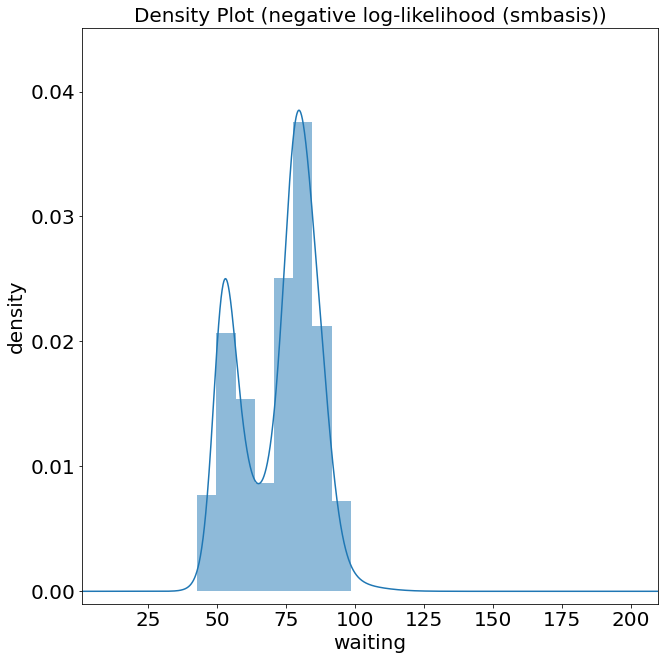

**************************************************
log penalty = -15.0
start time = 08:47:07
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.2839791732220795, Relative Error = 0.3533216017129853
Iter = 3, GradNorm = 0.15339123191554396, Relative Error = 0.19084651572932387
Iter = 4, GradNorm = 0.07738529952407897, Relative Error = 0.09628134932101019
Iter = 5, GradNorm = 0.06575725037024742, Relative Error = 0.08181394699282547
Iter = 6, GradNorm = 0.07436795950166786, Relative Error = 0.09252723102587285
Iter = 7, GradNorm = 0.06146949873855082, Relative Error = 0.07647920621916397
Iter = 8, GradNorm = 0.06762510292189743, Relative Error = 0.08413789437186994
Iter = 9, GradNorm = 0.08431365473183373, Relative Error = 0.10490147991532692
Iter = 10, GradNorm = 0.07880506551081569, Relative Error = 0.09804779573607579
Iter = 11, GradNorm = 0.04528833816956285, Relative Error = 0.056346907413790455
end time = 08:49:57


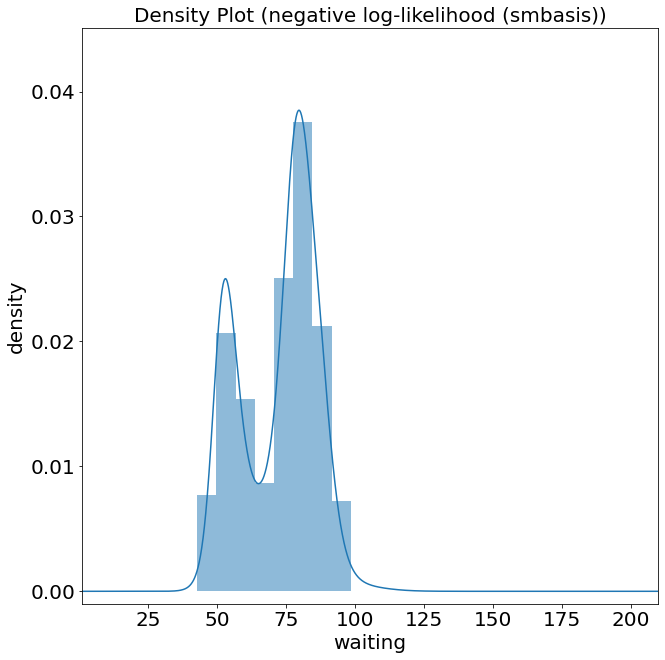

**************************************************
log penalty = -14.0
start time = 08:50:01
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.2839789682665281, Relative Error = 0.353321346711103
Iter = 3, GradNorm = 0.1533904269540001, Relative Error = 0.19084551421115348
Iter = 4, GradNorm = 0.07738453193535198, Relative Error = 0.09628039430140295
Iter = 5, GradNorm = 0.0657563379354216, Relative Error = 0.08181281175839802
Iter = 6, GradNorm = 0.0743673155106577, Relative Error = 0.0925264297842444
Iter = 7, GradNorm = 0.06146891285086335, Relative Error = 0.07647847726860815
Iter = 8, GradNorm = 0.06762469211057451, Relative Error = 0.08413738324806826
Iter = 9, GradNorm = 0.08431334722768855, Relative Error = 0.10490109732439296
Iter = 10, GradNorm = 0.0788046465911837, Relative Error = 0.09804727452406689
Iter = 11, GradNorm = 0.04528787066072985, Relative Error = 0.05634632574800202
end time = 08:52:48


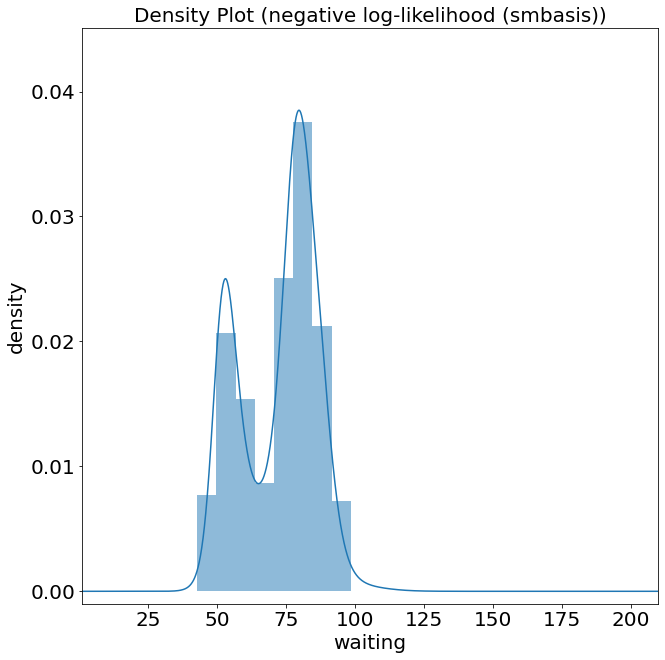

**************************************************
log penalty = -13.0
start time = 08:52:51
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.28397841123538287, Relative Error = 0.35332065366331994
Iter = 3, GradNorm = 0.1533882389623508, Relative Error = 0.19084279195266776
Iter = 4, GradNorm = 0.07738244552010065, Relative Error = 0.096277798422381
Iter = 5, GradNorm = 0.0657538577464056, Relative Error = 0.08180972595338726
Iter = 6, GradNorm = 0.07436556501524942, Relative Error = 0.0925242518504388
Iter = 7, GradNorm = 0.061467320325355616, Relative Error = 0.07647649587801258
Iter = 8, GradNorm = 0.06762357551436625, Relative Error = 0.08413599399984878
Iter = 9, GradNorm = 0.08431251144213799, Relative Error = 0.10490005745556714
Iter = 10, GradNorm = 0.07880350796661896, Relative Error = 0.09804585786857628
Iter = 11, GradNorm = 0.04528660002400401, Relative Error = 0.05634474484543767
end time = 08:55:42


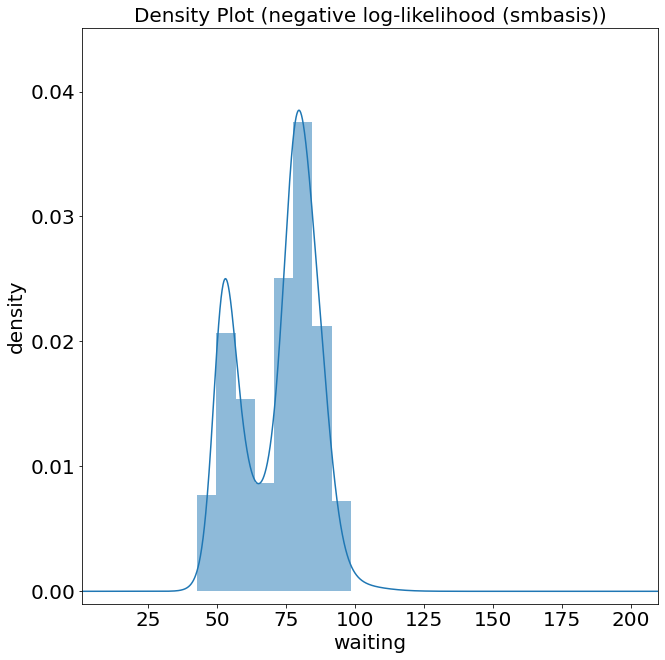

**************************************************
log penalty = -12.0
start time = 08:55:45
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.28397689777566415, Relative Error = 0.35331877064490746
Iter = 3, GradNorm = 0.15338229227621836, Relative Error = 0.1908353931964655
Iter = 4, GradNorm = 0.07737677484787295, Relative Error = 0.09627074307754163
Iter = 5, GradNorm = 0.0657471163812766, Relative Error = 0.08180133847236855
Iter = 6, GradNorm = 0.07436080707177814, Relative Error = 0.09251833210572985
Iter = 7, GradNorm = 0.06146299200059325, Relative Error = 0.07647111065690491
Iter = 8, GradNorm = 0.06762054106504137, Relative Error = 0.08413221859447796
Iter = 9, GradNorm = 0.08431024026088096, Relative Error = 0.1048972316941199
Iter = 10, GradNorm = 0.07880041372895218, Relative Error = 0.09804200807566328
Iter = 11, GradNorm = 0.04528314743490752, Relative Error = 0.056340449198345716
end time = 08:58:34


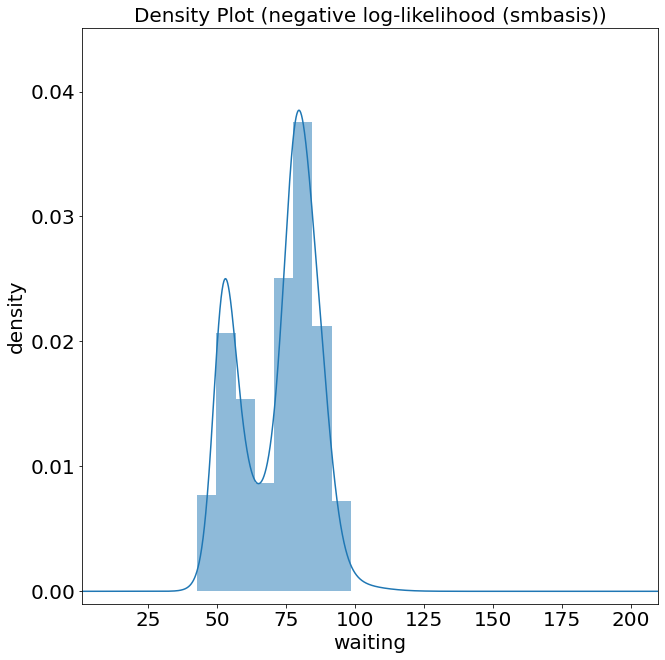

**************************************************
log penalty = -11.0
start time = 08:58:37
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.28397278899659495, Relative Error = 0.3533136585784649
Iter = 3, GradNorm = 0.15336613409773245, Relative Error = 0.1908152894915401
Iter = 4, GradNorm = 0.07736136621909945, Relative Error = 0.09625157194841732
Iter = 5, GradNorm = 0.06572879505375238, Relative Error = 0.0817785434176717
Iter = 6, GradNorm = 0.07434787656849501, Relative Error = 0.09250224421421614
Iter = 7, GradNorm = 0.061451230887946316, Relative Error = 0.07645647769945528
Iter = 8, GradNorm = 0.06761229829237984, Relative Error = 0.08412196309015248
Iter = 9, GradNorm = 0.08430407186346328, Relative Error = 0.10488955708886315
Iter = 10, GradNorm = 0.07879200910594578, Relative Error = 0.09803155120015117
Iter = 11, GradNorm = 0.04527377236600931, Relative Error = 0.056328784912117597
end time = 09:01:25


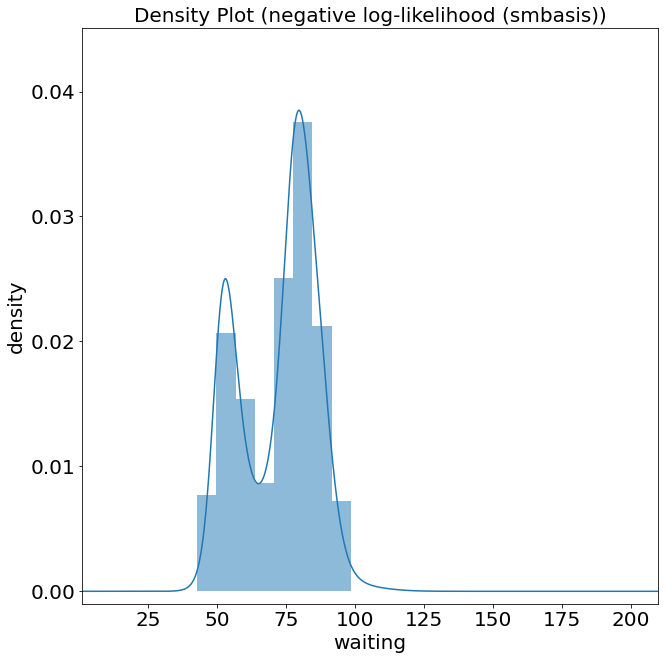

**************************************************
log penalty = -10.0
start time = 09:01:28
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.28396165883141883, Relative Error = 0.3532998106341148
Iter = 3, GradNorm = 0.1533222603262787, Relative Error = 0.19076070256170527
Iter = 4, GradNorm = 0.07731952452039069, Relative Error = 0.09619951328566952
Iter = 5, GradNorm = 0.06567901914082577, Relative Error = 0.08171661315327092
Iter = 6, GradNorm = 0.07431274943262643, Relative Error = 0.09245853968557816
Iter = 7, GradNorm = 0.0614192940446472, Relative Error = 0.07641674247345237
Iter = 8, GradNorm = 0.06758993430171464, Relative Error = 0.08409413822922035
Iter = 9, GradNorm = 0.08428734363116039, Relative Error = 0.10486874413358892
Iter = 10, GradNorm = 0.07876921010532877, Relative Error = 0.09800318510793371
Iter = 11, GradNorm = 0.045248362380902775, Relative Error = 0.05629717028159565
end time = 09:04:15


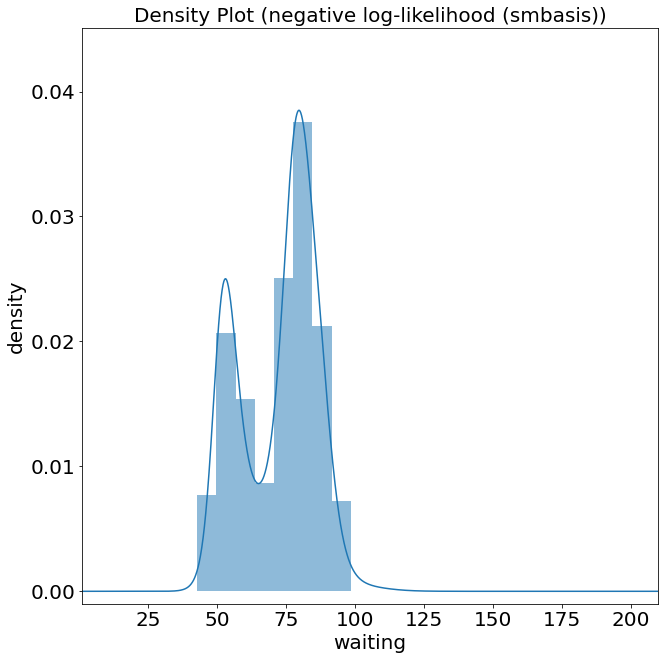

**************************************************
log penalty = -9.0
start time = 09:04:18
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.28393168957011317, Relative Error = 0.3532625234370062
Iter = 3, GradNorm = 0.15320335928214565, Relative Error = 0.19061276809566055
Iter = 4, GradNorm = 0.07720610737495276, Relative Error = 0.09605840178431126
Iter = 5, GradNorm = 0.06554391081784697, Relative Error = 0.08154851389254698
Iter = 6, GradNorm = 0.0742174233220608, Relative Error = 0.0923399367130856
Iter = 7, GradNorm = 0.06133272523289352, Relative Error = 0.07630903516914495
Iter = 8, GradNorm = 0.06752945348468167, Relative Error = 0.08401888912237727
Iter = 9, GradNorm = 0.08424216030349417, Relative Error = 0.10481252787828886
Iter = 10, GradNorm = 0.07870758305221287, Relative Error = 0.09792650987549076
Iter = 11, GradNorm = 0.045179836333032686, Relative Error = 0.05621191144828823
end time = 09:07:07


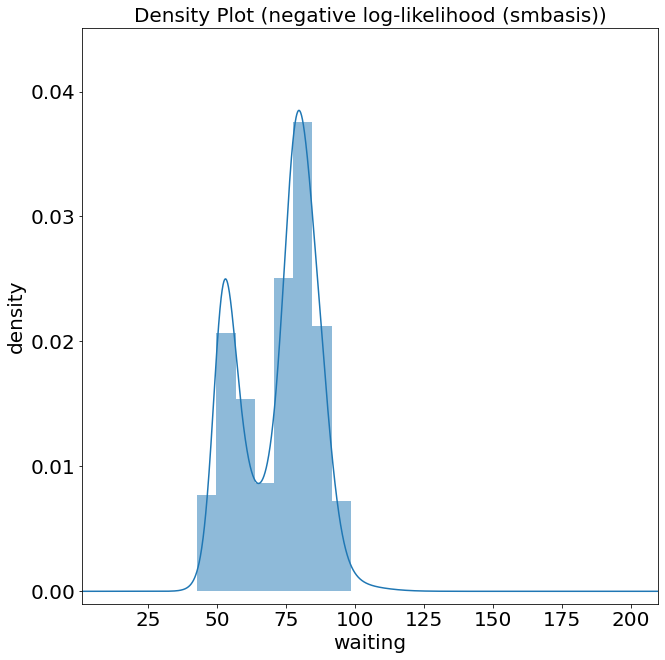

**************************************************
log penalty = -8.0
start time = 09:07:11
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.2838523363654456, Relative Error = 0.35316379365673367
Iter = 3, GradNorm = 0.1528828205191345, Relative Error = 0.19021395973280347
Iter = 4, GradNorm = 0.07690018424342558, Relative Error = 0.09567777791811066
Iter = 5, GradNorm = 0.06517810030248213, Relative Error = 0.08109337925803953
Iter = 6, GradNorm = 0.07395946989788715, Relative Error = 0.09201899586393006
Iter = 7, GradNorm = 0.06109920146842366, Relative Error = 0.07601848924789172
Iter = 8, GradNorm = 0.06736732773818013, Relative Error = 0.08381717528617266
Iter = 9, GradNorm = 0.08412145258779345, Relative Error = 0.1046623455851066
Iter = 10, GradNorm = 0.07854260351524245, Relative Error = 0.09772124540630142
Iter = 11, GradNorm = 0.044997552919423506, Relative Error = 0.055985117817856256
end time = 09:10:01


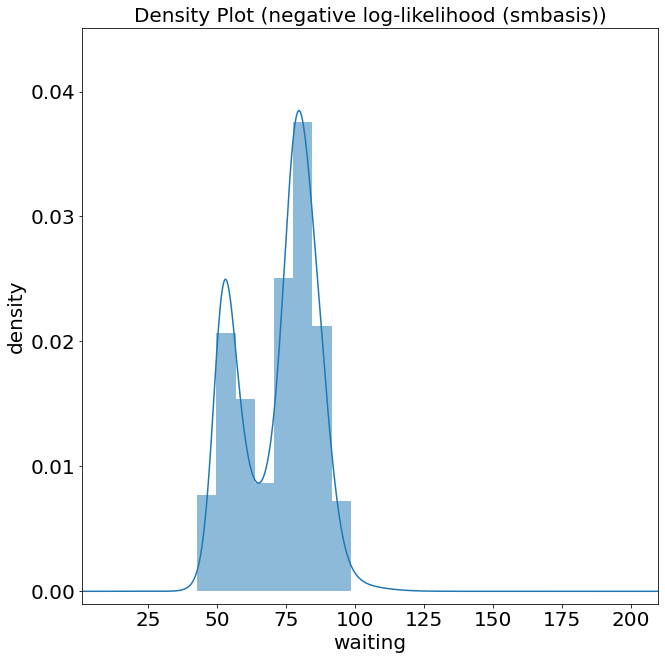

**************************************************
log penalty = -7.0
start time = 09:10:04
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.2836522528436324, Relative Error = 0.3529148534629817
Iter = 3, GradNorm = 0.15203133886260836, Relative Error = 0.18915456210409862
Iter = 4, GradNorm = 0.07608634931698498, Relative Error = 0.09466521965027215
Iter = 5, GradNorm = 0.06419443599858031, Relative Error = 0.0798695224397415
Iter = 6, GradNorm = 0.0732667719774815, Relative Error = 0.09115715400431741
Iter = 7, GradNorm = 0.060477434774604384, Relative Error = 0.0752448987001785
Iter = 8, GradNorm = 0.06694308935067646, Relative Error = 0.08328934578064863
Iter = 9, GradNorm = 0.08380855254773648, Relative Error = 0.10427304117917212
Iter = 10, GradNorm = 0.0781124331979451, Relative Error = 0.09718603550413714
Iter = 11, GradNorm = 0.044530727747434606, Relative Error = 0.05540430262772937
end time = 09:12:57


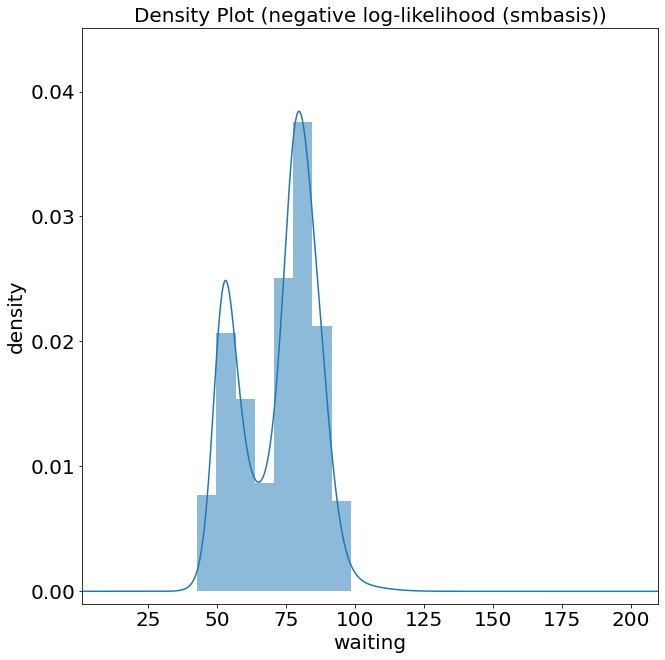

**************************************************
log penalty = -6.0
start time = 09:13:00
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.28322410363770667, Relative Error = 0.35238215818996776
Iter = 3, GradNorm = 0.149865729060919, Relative Error = 0.18646015069661187
Iter = 4, GradNorm = 0.07400920550949305, Relative Error = 0.09208087598617772
Iter = 5, GradNorm = 0.061599514533383325, Relative Error = 0.07664096945115381
Iter = 6, GradNorm = 0.07144358210997566, Relative Error = 0.08888877510559343
Iter = 7, GradNorm = 0.05887859852743434, Relative Error = 0.07325565640005699
Iter = 8, GradNorm = 0.06590427945932614, Relative Error = 0.08199687784885368
Iter = 9, GradNorm = 0.08306275675979982, Relative Error = 0.10334513594107035
Iter = 10, GradNorm = 0.07706908674987611, Relative Error = 0.09588792327291022
Iter = 11, GradNorm = 0.04345795623672447, Relative Error = 0.05406958028124324
end time = 09:15:49


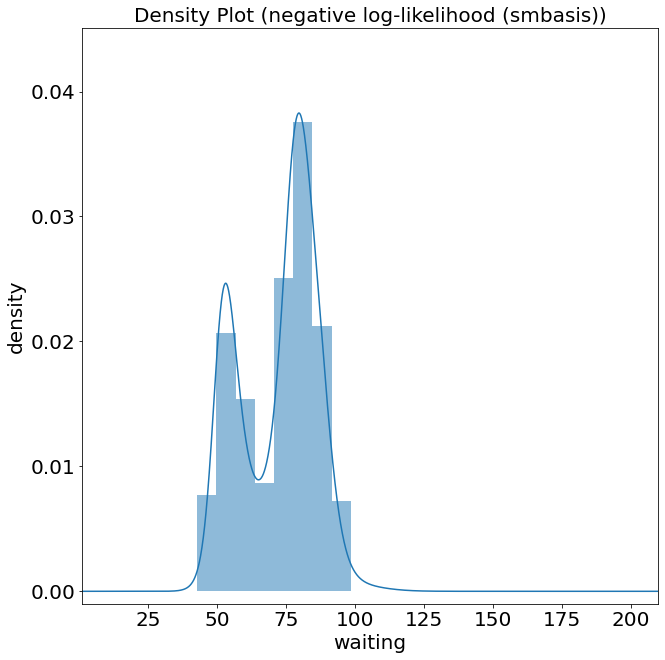

In [9]:
waiting = waiting.reshape(-1, 1)
loss_vals_list = []

for log_pen_param in ml_log_pen_param_list: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))
    
#     # compute value of loss functional
#     np.random.seed(seed_no)
#     loss_val = nll_pen.eval_loss_function(
#         new_data=waiting, 
#         coef=nll_pen_coef, 
#         batchmc_params=bmc_params, 
#         batch_mc=True)
    
#     true_loss = loss_val + np.exp(log_pen_param) * np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item() / 2 
#     loss_vals_list.append(true_loss)
    
#     print(true_loss)
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

In [ ]:
# gap = 1
loss_vals_list

**************************************************
log penalty = -9.5
start time = 09:15:52
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.283950295135014, Relative Error = 0.3532856721345567
Iter = 3, GradNorm = 0.15327730843272724, Relative Error = 0.19070477425242321
Iter = 4, GradNorm = 0.07727664985374194, Relative Error = 0.09614616942343705
Iter = 5, GradNorm = 0.0656279764760368, Relative Error = 0.08165310681978062
Iter = 6, GradNorm = 0.07427673260573642, Relative Error = 0.09241372821993082
Iter = 7, GradNorm = 0.06138656883877467, Relative Error = 0.07637602638140914
Iter = 8, GradNorm = 0.06756704701396671, Relative Error = 0.08406566229179785
Iter = 9, GradNorm = 0.08427023557003269, Relative Error = 0.10484745860236049
Iter = 10, GradNorm = 0.0787458838651415, Relative Error = 0.09797416303405626
Iter = 11, GradNorm = 0.04522239747449089, Relative Error = 0.05626486522831415
end time = 09:18:40


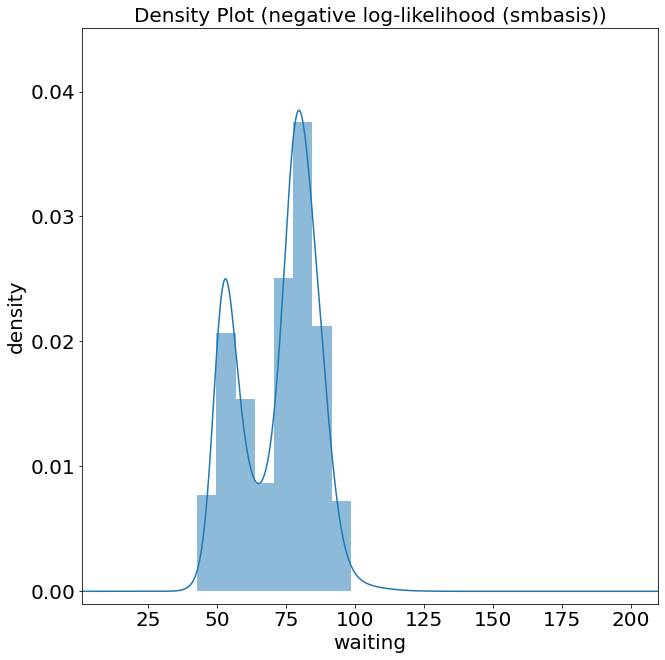

2.1032652055610983
**************************************************
log penalty = -8.5
start time = 09:18:51
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.2839013676397235, Relative Error = 0.35322479745558744
Iter = 3, GradNorm = 0.15308188402164222, Relative Error = 0.19046163083752082
Iter = 4, GradNorm = 0.07709019984752627, Relative Error = 0.09591419179603548
Iter = 5, GradNorm = 0.06540555309908372, Relative Error = 0.08137637179406795
Iter = 6, GradNorm = 0.07411983508497609, Relative Error = 0.09221851924488221
Iter = 7, GradNorm = 0.061244253225771365, Relative Error = 0.0761989599445836
Iter = 8, GradNorm = 0.06746785460070841, Relative Error = 0.08394224893745728
Iter = 9, GradNorm = 0.08419622686910265, Relative Error = 0.10475537835416267
Iter = 10, GradNorm = 0.07864486222286508, Relative Error = 0.09784847378701818
Iter = 11, GradNorm = 0.04511033495301185, Relative Error = 0.05612543912487238
end time = 09:21:39


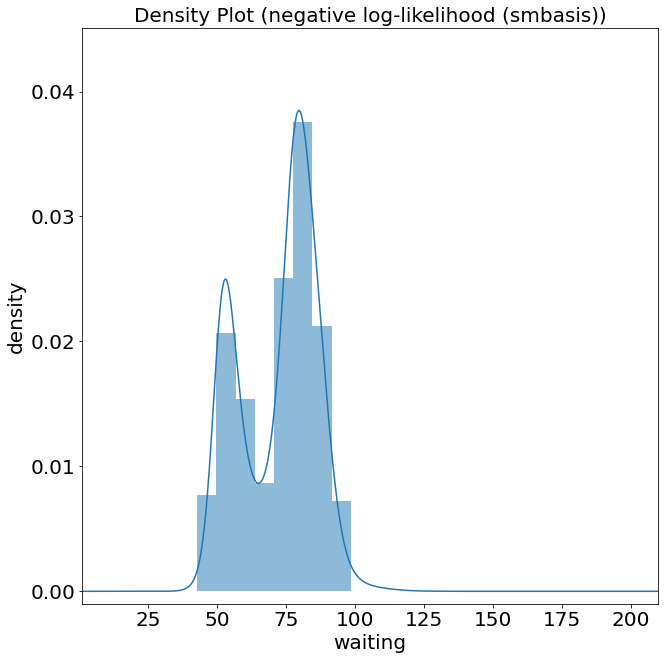

2.099749063945568
**************************************************
log penalty = -7.5
start time = 09:21:50
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.2837741115628782, Relative Error = 0.3530664678133515
Iter = 3, GradNorm = 0.15255793395138142, Relative Error = 0.18980974191221078
Iter = 4, GradNorm = 0.0765898626778374, Relative Error = 0.09529168160211797
Iter = 5, GradNorm = 0.06480488804924474, Relative Error = 0.08062903551903715
Iter = 6, GradNorm = 0.07369650216090111, Relative Error = 0.09169181630010308
Iter = 7, GradNorm = 0.06086224374592003, Relative Error = 0.075723670859968
Iter = 8, GradNorm = 0.06720436304143147, Relative Error = 0.0836144176436857
Iter = 9, GradNorm = 0.0840007393172982, Relative Error = 0.10451215638075238
Iter = 10, GradNorm = 0.07837709477393005, Relative Error = 0.09751532251091971
Iter = 11, GradNorm = 0.04481644978194579, Relative Error = 0.05575979266501896
end time = 09:24:39


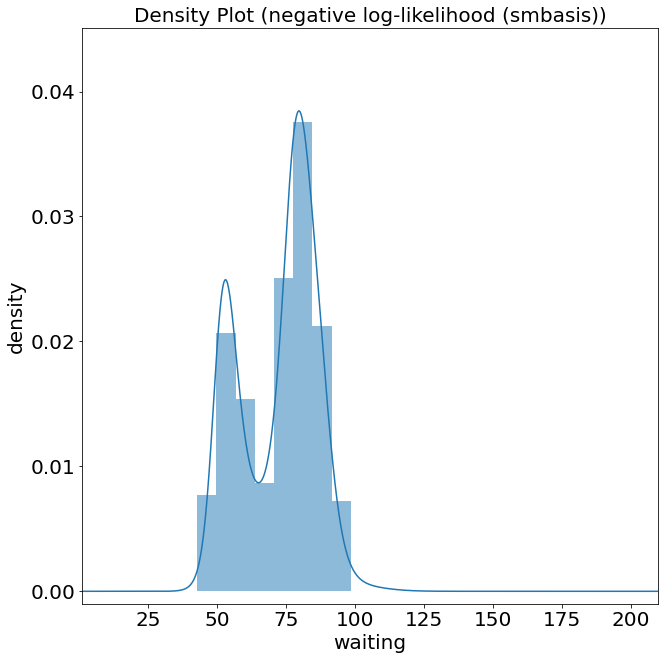

2.0902706540374565
**************************************************
log penalty = -6.5
start time = 09:24:50
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.2834707012234762, Relative Error = 0.3526889703163433
Iter = 3, GradNorm = 0.1511879374551566, Relative Error = 0.1881052177708971
Iter = 4, GradNorm = 0.07527859374247056, Relative Error = 0.09366022519894723
Iter = 5, GradNorm = 0.06320119222576333, Relative Error = 0.0786337470245187
Iter = 6, GradNorm = 0.07256842923279694, Relative Error = 0.09028828895940218
Iter = 7, GradNorm = 0.05985853801212882, Relative Error = 0.07447487886762606
Iter = 8, GradNorm = 0.06653185730061702, Relative Error = 0.0827776985180901
Iter = 9, GradNorm = 0.08350962793006526, Relative Error = 0.10390112473365011
Iter = 10, GradNorm = 0.07769764449292402, Relative Error = 0.09666996311767416
Iter = 11, GradNorm = 0.044093314981426414, Relative Error = 0.05486008180568035
end time = 09:27:41


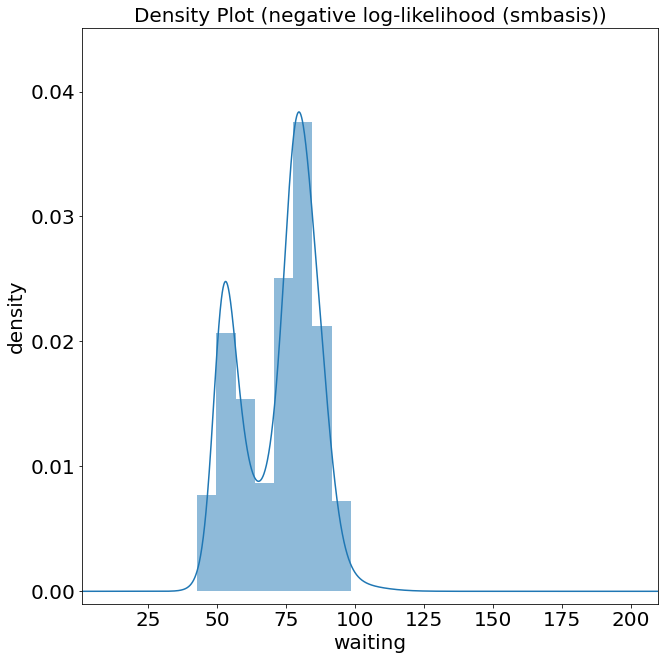

2.0650784791250523
**************************************************
log penalty = -5.5
start time = 09:27:51
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.2829612475575978, Relative Error = 0.3520551175475491
Iter = 3, GradNorm = 0.14787544710603864, Relative Error = 0.183983878932806
Iter = 4, GradNorm = 0.07209284351315484, Relative Error = 0.08969657405894235
Iter = 5, GradNorm = 0.059056632119359964, Relative Error = 0.0734771624814508
Iter = 6, GradNorm = 0.06965634079536798, Relative Error = 0.08666512272728687
Iter = 7, GradNorm = 0.05736486279347146, Relative Error = 0.07137229457452025
Iter = 8, GradNorm = 0.06499500924332562, Relative Error = 0.08086558077005
Iter = 9, GradNorm = 0.08243915999747975, Relative Error = 0.1025692684561909
Iter = 10, GradNorm = 0.07616933747506091, Relative Error = 0.09476847197191923
Iter = 11, GradNorm = 0.04261961378141922, Relative Error = 0.05302653020214182
end time = 09:30:41


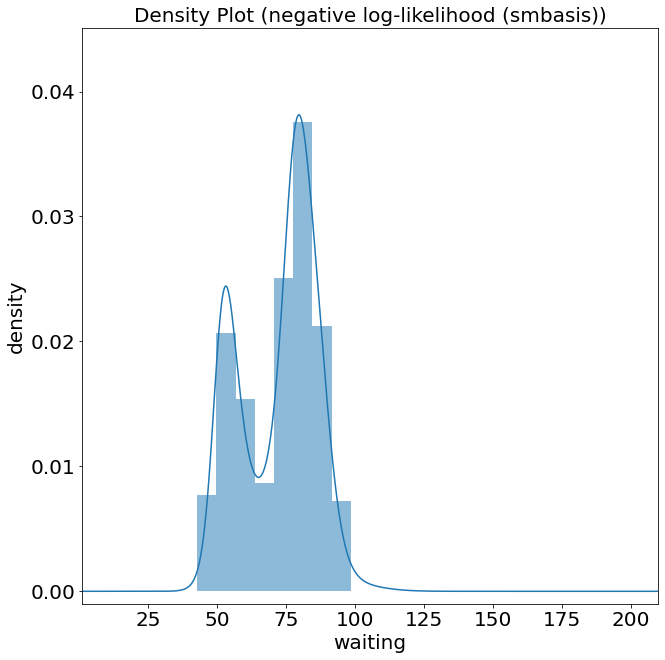

2.0005608802763963


In [10]:
waiting = waiting.reshape(-1, 1)
loss_vals_list = []

ml_log_pen_param_list = [-9.5, -8.5, -7.5, -6.5, -5.5]

for log_pen_param in ml_log_pen_param_list: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))
    
    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    loss_vals_list.append(loss_val)

    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -5.0
start time = 09:30:51
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.268819188885873, Relative Error = 0.3344598313696248
Iter = 3, GradNorm = 0.1667072574940183, Relative Error = 0.2074140669073052
Iter = 4, GradNorm = 0.09296142183256698, Relative Error = 0.11566087078404562
Iter = 5, GradNorm = 0.07304381221982885, Relative Error = 0.09087975162372182
Iter = 6, GradNorm = 0.07586275651367148, Relative Error = 0.094387029646048
Iter = 7, GradNorm = 0.05634074238899376, Relative Error = 0.07009810302888167
Iter = 8, GradNorm = 0.05949487789593773, Relative Error = 0.07402241971974594
Iter = 9, GradNorm = 0.07114704255111269, Relative Error = 0.08851982610584833
Iter = 10, GradNorm = 0.0639104880194243, Relative Error = 0.07951623964910491
Iter = 11, GradNorm = 0.02938553650299802, Relative Error = 0.03656093757381011
end time = 09:33:43


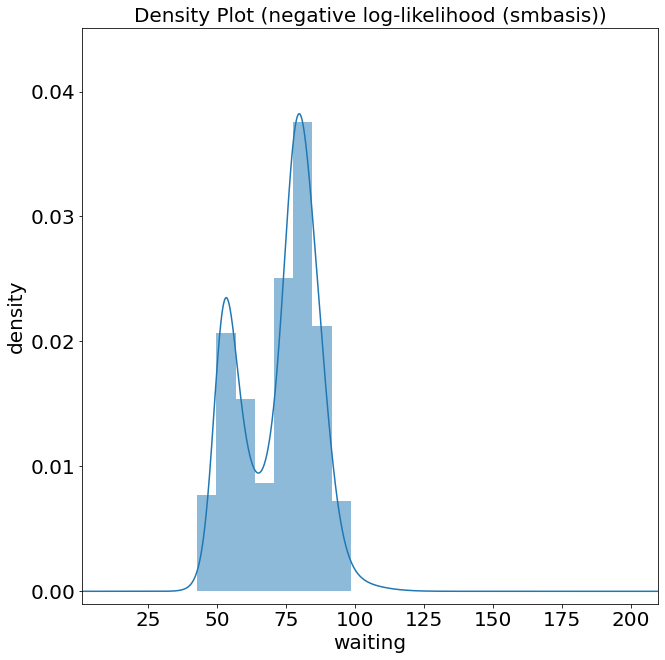

loss_val=-0.2360401215091699
1.9001823492327121
**************************************************
log penalty = -4.5
start time = 09:33:54
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.26237344614111946, Relative Error = 0.3264401582190689
Iter = 3, GradNorm = 0.1571537257000924, Relative Error = 0.1955277404660133
Iter = 4, GradNorm = 0.08614517554558836, Relative Error = 0.10718022402231252
Iter = 5, GradNorm = 0.06684304397880095, Relative Error = 0.08316487119107237
Iter = 6, GradNorm = 0.07205581683304334, Relative Error = 0.0896505061527129
Iter = 7, GradNorm = 0.05310681680953307, Relative Error = 0.06607451301489818
Iter = 8, GradNorm = 0.05727389810945006, Relative Error = 0.07125911800775625
Iter = 9, GradNorm = 0.06936097150532113, Relative Error = 0.08629762975422095
Iter = 10, GradNorm = 0.06221092141947225, Relative Error = 0.07740167051891259
Iter = 11, GradNorm = 0.026130732910673905, Relative Error = 0.032511371524817465
end time

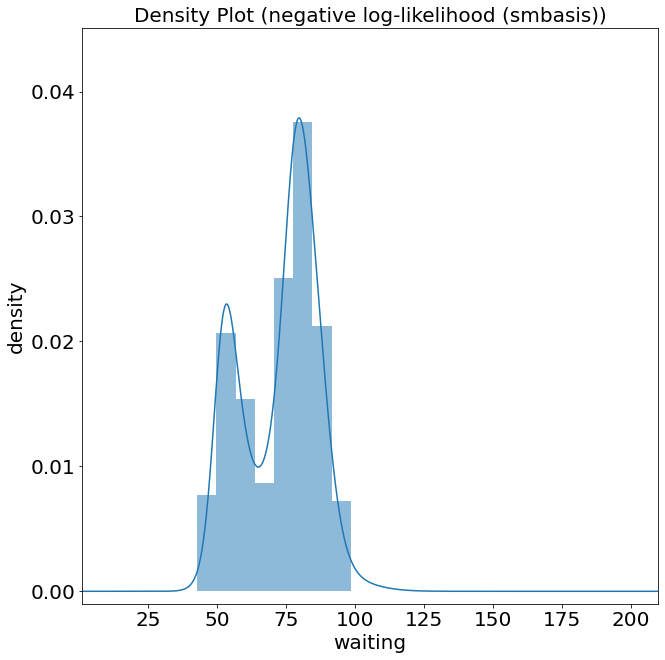

loss_val=-0.23440324486901834
1.8181370852014718
**************************************************
log penalty = -4.0
start time = 09:36:52
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.2536386527442545, Relative Error = 0.31557249085249467
Iter = 3, GradNorm = 0.131725463921216, Relative Error = 0.16389037044851668
Iter = 4, GradNorm = 0.08432749718551406, Relative Error = 0.104918702438551
Iter = 5, GradNorm = 0.05841788853076817, Relative Error = 0.07268244959724691
Iter = 6, GradNorm = 0.06657438931439623, Relative Error = 0.08283061605799996
Iter = 7, GradNorm = 0.04897964935595502, Relative Error = 0.06093956808675187
end time = 09:38:38


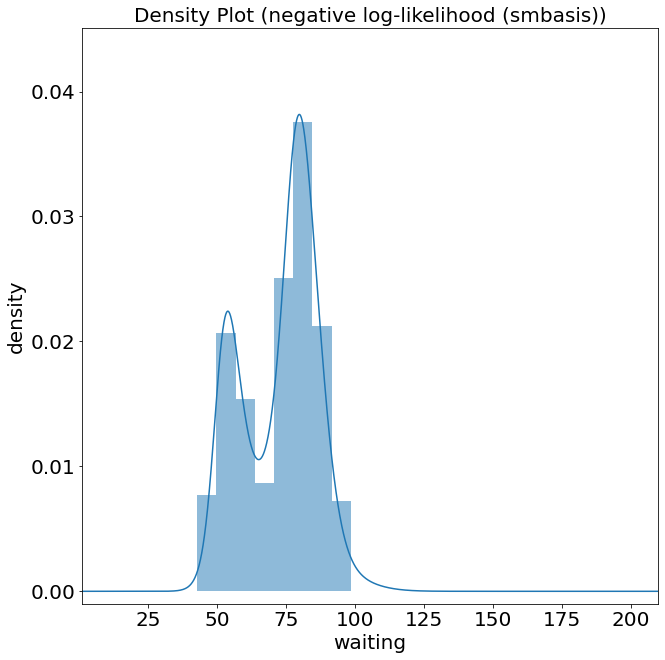

loss_val=-0.24590784283230013
1.68795167725582


In [11]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.5, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

for log_pen_param in [-5., -4.5, -4.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -3.5
start time = 09:38:48
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.4972001574700399, Relative Error = 0.6186071817030154
Iter = 3, GradNorm = 0.33741440760811775, Relative Error = 0.4198047257638441
Iter = 4, GradNorm = 0.253079721691134, Relative Error = 0.3148770792394
Iter = 5, GradNorm = 0.19463337942122017, Relative Error = 0.242159228029508
Iter = 6, GradNorm = 0.15637642506550267, Relative Error = 0.194560637484095
Iter = 7, GradNorm = 0.11440008495572124, Relative Error = 0.14233445641116596
Iter = 8, GradNorm = 0.11728915206343181, Relative Error = 0.145928979933334
Iter = 9, GradNorm = 0.09423379235305124, Relative Error = 0.11724393050342272
Iter = 10, GradNorm = 0.06331479888599915, Relative Error = 0.07877509431666112
Iter = 11, GradNorm = 0.08430135030376994, Relative Error = 0.10488617097494818
Iter = 12, GradNorm = 0.05832835935461584, Relative Error = 0.0725710

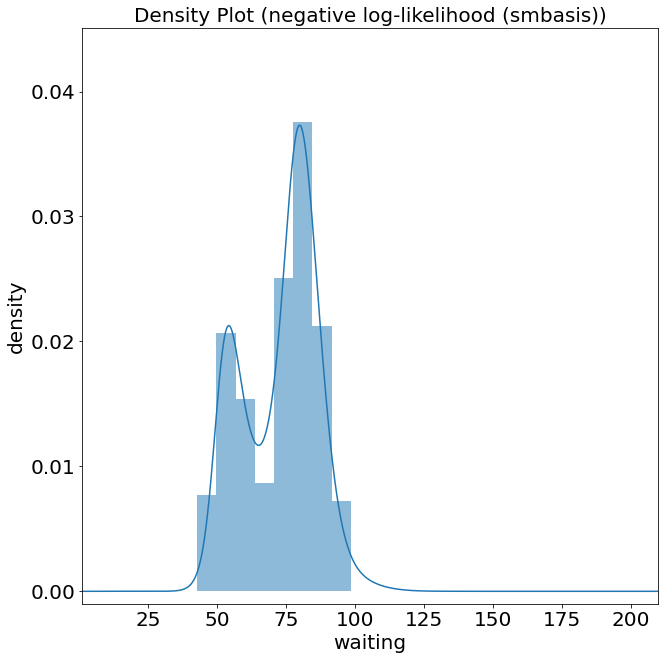

loss_val=-0.22969993364827695
1.54476881006415
**************************************************
log penalty = -3.0
start time = 09:42:57
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.469627071926636, Relative Error = 0.5843012618785852
Iter = 3, GradNorm = 0.30608289727384935, Relative Error = 0.3808226437689312
Iter = 4, GradNorm = 0.22145018672013725, Relative Error = 0.2755242005385032
Iter = 5, GradNorm = 0.1640408171522525, Relative Error = 0.20409653146364767
Iter = 6, GradNorm = 0.12922122201612263, Relative Error = 0.1607746392808214
Iter = 7, GradNorm = 0.09120128196861274, Relative Error = 0.11347093752621179
Iter = 8, GradNorm = 0.09552562851412269, Relative Error = 0.1188512090105109
Iter = 9, GradNorm = 0.07495595075565216, Relative Error = 0.09325879879999441
Iter = 10, GradNorm = 0.049868700957213685, Relative Error = 0.06204570954141606
end time = 09:45:24


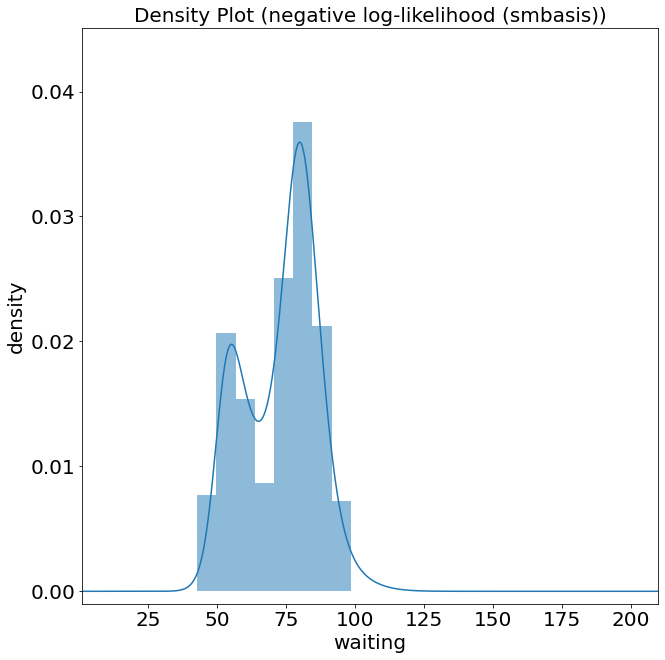

loss_val=-0.2030439749229226
1.3034212761400652
**************************************************
log penalty = -2.5
start time = 09:45:34
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.4245632912350072, Relative Error = 0.5282337446992266
Iter = 3, GradNorm = 0.2593962854933602, Relative Error = 0.32273603035402804
Iter = 4, GradNorm = 0.17715791539881615, Relative Error = 0.22041658095783404
Iter = 5, GradNorm = 0.12343256968454235, Relative Error = 0.1535725057921303
Iter = 6, GradNorm = 0.09594072038924024, Relative Error = 0.11936765859556511
Iter = 7, GradNorm = 0.06538941388562407, Relative Error = 0.08135629168507527
Iter = 8, GradNorm = 0.07260096425131352, Relative Error = 0.09032876842387702
Iter = 9, GradNorm = 0.06094851921681348, Relative Error = 0.07583101319503699
Iter = 10, GradNorm = 0.03601713915228793, Relative Error = 0.044811854158241564
end time = 09:47:57


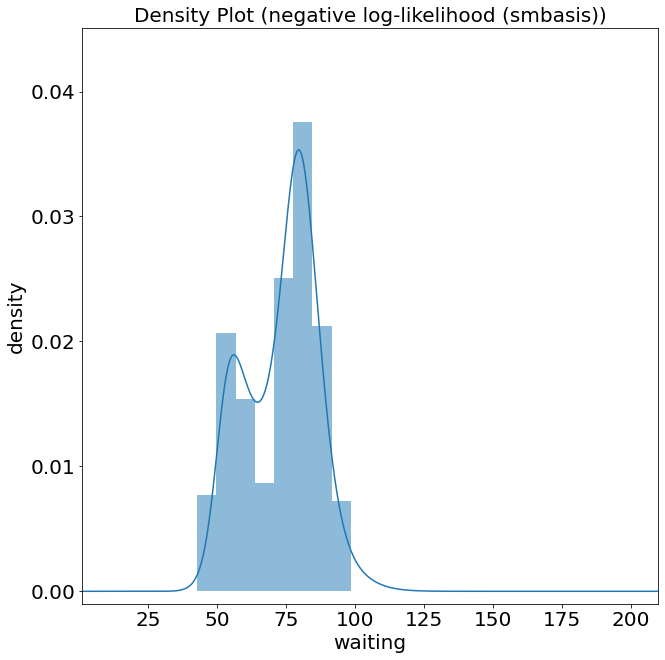

loss_val=-0.18782413498287334
1.12844561272816
**************************************************
log penalty = -2.0
start time = 09:48:08
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.3517921110006373, Relative Error = 0.4376931967174043
Iter = 3, GradNorm = 0.19567457055950327, Relative Error = 0.24345465866441537
Iter = 4, GradNorm = 0.1227556574482735, Relative Error = 0.15273030418690697
Iter = 5, GradNorm = 0.07757723882036682, Relative Error = 0.09652015662094925
Iter = 6, GradNorm = 0.06359639535144752, Relative Error = 0.0791254513977106
Iter = 7, GradNorm = 0.0448408231663271, Relative Error = 0.05579011757621249
end time = 09:49:53


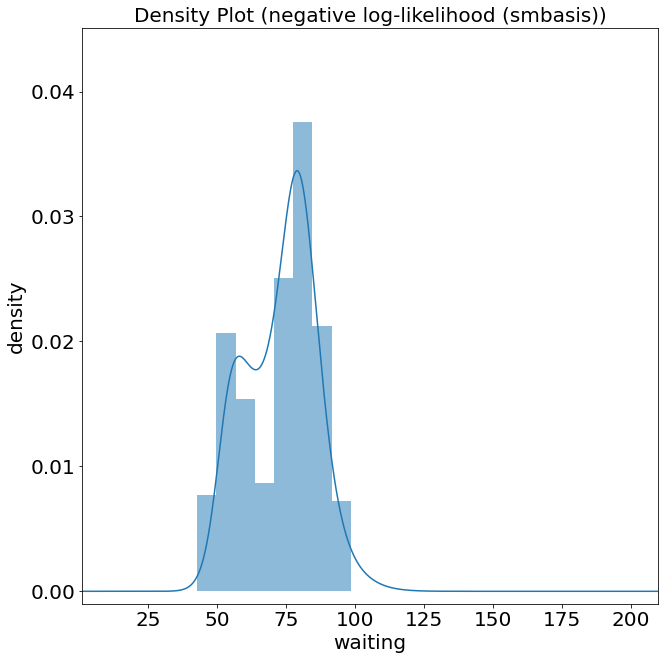

loss_val=-0.17702286919129537
0.8802082129513809
**************************************************
log penalty = -1.5
start time = 09:50:03
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.24006357490702568, Relative Error = 0.29868263167582454
Iter = 3, GradNorm = 0.12323613257327075, Relative Error = 0.1533281023945048
Iter = 4, GradNorm = 0.07236077213571926, Relative Error = 0.09002992586427064
Iter = 5, GradNorm = 0.04093373467619057, Relative Error = 0.05092899079812355
end time = 09:51:20


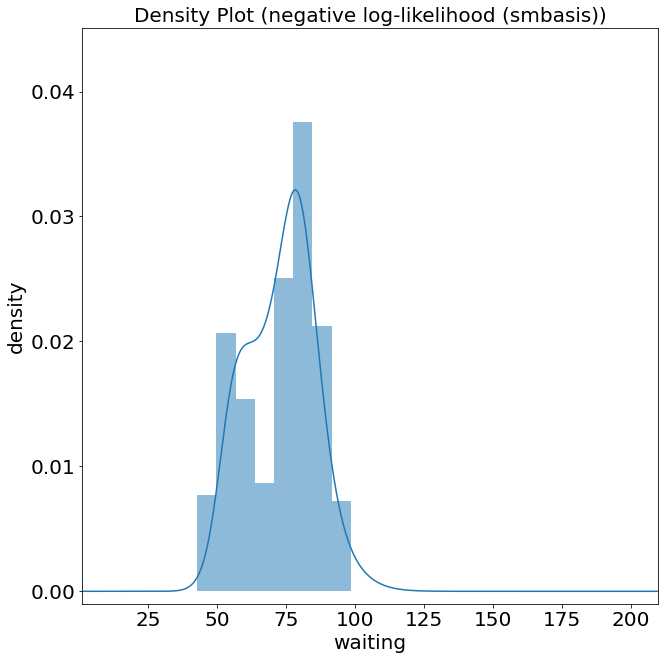

loss_val=-0.1446723939092858
0.677632532412175


In [12]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.2, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

for log_pen_param in [-3.5, -3., -2.5, -2., -1.5]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -1.0
start time = 09:51:30
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.404452891879914, Relative Error = 0.503212760129796
Iter = 3, GradNorm = 0.2235002808184431, Relative Error = 0.2780748894578955
Iter = 4, GradNorm = 0.14582069869122918, Relative Error = 0.18142739919944909
Iter = 5, GradNorm = 0.07850860251063277, Relative Error = 0.09767894198921545
Iter = 6, GradNorm = 0.060279107719686593, Relative Error = 0.07499814386984532
Iter = 7, GradNorm = 0.045065705676522114, Relative Error = 0.05606991220973374
end time = 09:53:10


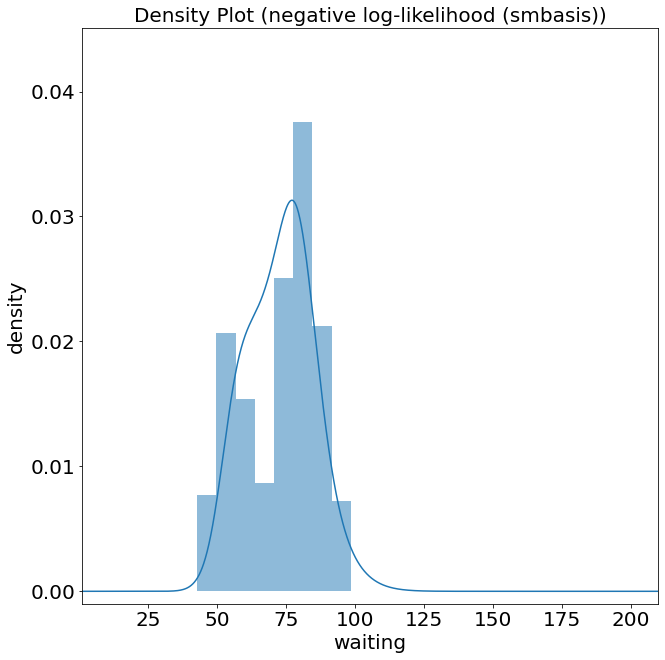

loss_val=-0.1104377157562556
0.48562426181959306
**************************************************
log penalty = -0.5
start time = 09:53:21
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.24458692951224695, Relative Error = 0.3043105052839456
Iter = 3, GradNorm = 0.11549339255083663, Relative Error = 0.1436947293716378
Iter = 4, GradNorm = 0.0642297813373507, Relative Error = 0.07991349845236859
Iter = 5, GradNorm = 0.028761742605709566, Relative Error = 0.035784824817272215
end time = 09:54:32


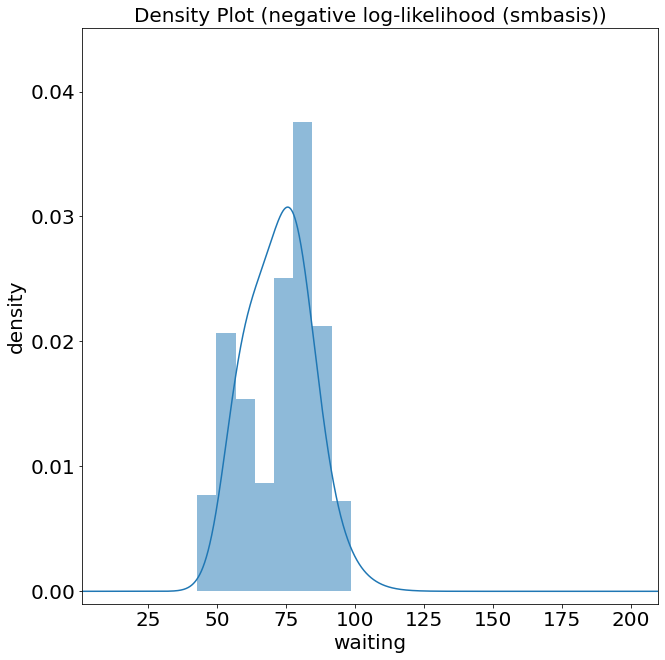

loss_val=-0.08206476707425688
0.34158802686679024
**************************************************
log penalty = 0.0
start time = 09:54:42
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.1562935345947019, Relative Error = 0.19445750670313747
Iter = 3, GradNorm = 0.05572648299681854, Relative Error = 0.06933385292614308
Iter = 4, GradNorm = 0.026836557807156713, Relative Error = 0.03338954572373727
end time = 09:55:38


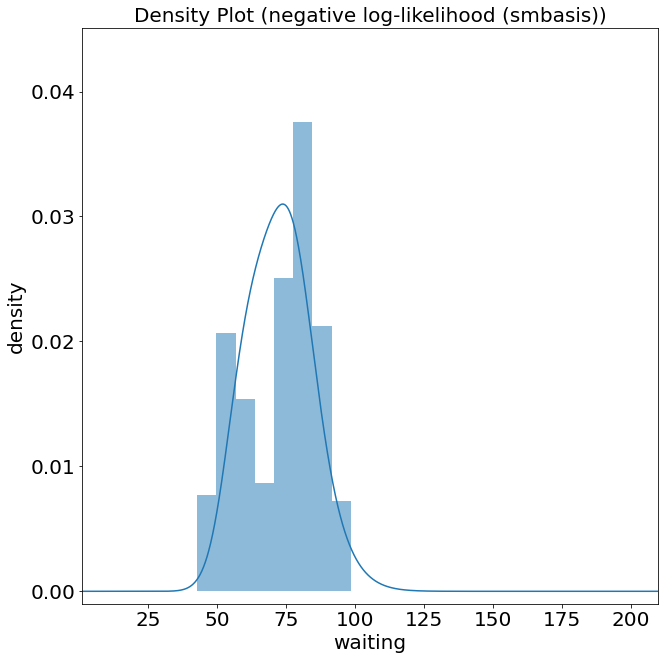

loss_val=-0.05847933804050566
0.23113430094316745


In [13]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.1, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

for log_pen_param in [-1., -0.5, 0.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = 0.5
start time = 09:55:48
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.17170041174319992, Relative Error = 0.2136264564882172
Iter = 3, GradNorm = 0.08419568085243645, Relative Error = 0.1047546990103894
Iter = 4, GradNorm = 0.04075599988046552, Relative Error = 0.0507078564734011
end time = 09:56:46


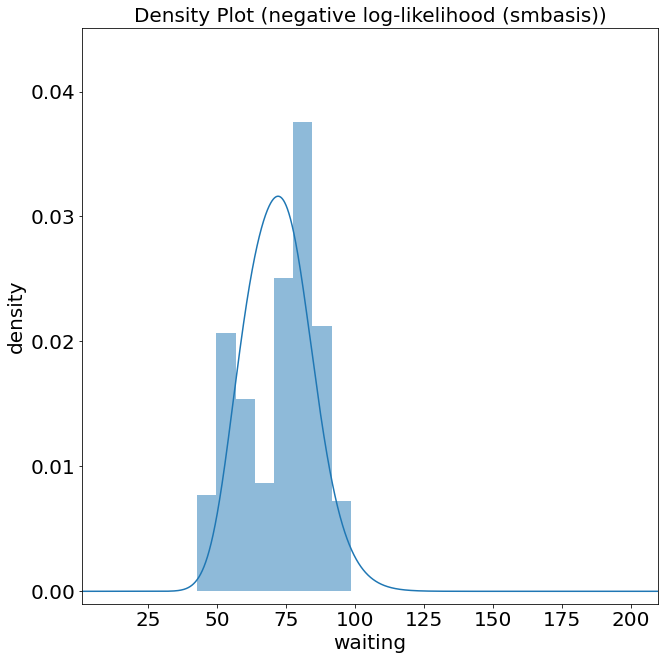

loss_val=-0.03838468569584021
0.14729226391708505
**************************************************
log penalty = 1.0
start time = 09:56:56
Iter = 1, GradNorm = 0.8037413275760169, Relative Error = 1.0
Iter = 2, GradNorm = 0.3103869466665549, Relative Error = 0.3861776619134953
Iter = 3, GradNorm = 0.1515864088373756, Relative Error = 0.18860098844803863
Iter = 4, GradNorm = 0.0781183237408573, Relative Error = 0.09719336440798979
Iter = 5, GradNorm = 0.050369658775456586, Relative Error = 0.06266899193471258
Iter = 6, GradNorm = 0.04428387671017147, Relative Error = 0.055097175161722856
end time = 09:58:22


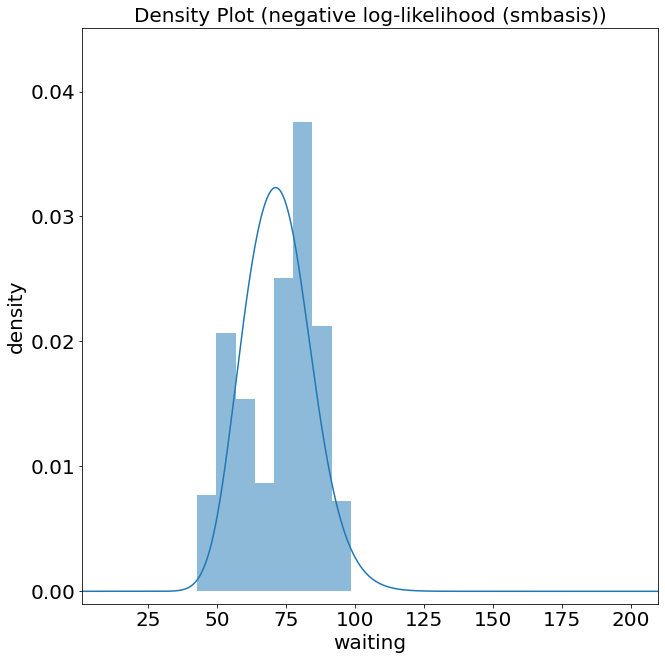

loss_val=-0.024472182989359922
0.0918515436792351


In [14]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.05, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05
)

for log_pen_param in [0.5, 1.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    